Title:
To Develop a Multi-Label Machine Learning Model for Predicting Adverse Drug Reaction (ADR) Risk Categories from Drug Chemical Structure Using the SIDER Database and Random Forest Classification

Objectives:

To understand adverse drug reactions as a multi-label prediction problem, where a single drug can be associated with multiple, simultaneous ADR categories rather than one single outcome.
To source and validate a real, peer-reviewed pharmacovigilance dataset (SIDER, via the MoleculeNet benchmark) linking drug chemical structures to 27 standardized MedDRA System Organ Class ADR categories.
To convert drug SMILES structures into Morgan fingerprints as numerical input features suitable for machine learning.
To train a multi-label Random Forest classifier capable of predicting the probability of a drug causing ADRs across all 27 organ-system categories simultaneously from its chemical structure alone.
To evaluate multi-label model performance using appropriate metrics — Hamming loss, micro- and macro-averaged F1-score, and per-category ROC-AUC — rather than relying on a single accuracy figure that would obscure category-by-category differences.
To critically interpret model performance, distinguishing categories the model predicts reliably from those it does not, and understanding why structure-based prediction has inherent scientific limits for ADRs driven by biological target or metabolic pathway effects rather than chemical similarity alone.
To apply the trained model as a screening tool for predicting the ADR risk profile of any drug, including novel molecules never seen during training.

Outcomes:

After completing this practical, a student will be able to:

Distinguish multi-label classification from standard binary/multi-class classification, and recognize when a real-world pharmaceutical problem (such as ADR prediction) requires this approach.
Explain how a single Random Forest model can be trained to predict multiple independent binary outcomes from one shared set of input features.
Correctly interpret Hamming loss, micro F1, macro F1, and per-label AUC, and explain what the gap between micro and macro scores reveals about class imbalance across ADR categories.
Identify which ADR categories a structure-based model can predict reliably, and explain — in terms of underlying pharmacology — why some categories (driven by shared metabolic pathways or specific biological targets) resist prediction from chemical structure alone better than others.
Use a trained multi-label model to generate a full predicted ADR risk profile for any drug, known or novel, directly from its SMILES structure.
Critically evaluate the real-world limitations of structure-only ADR prediction, and correctly position such a model as a preliminary screening aid rather than a replacement for curated pharmacovigilance databases or clinical judgment.

In [1]:
# Block 1: Load the ADR (SIDER) dataset from GitHub
import pandas as pd
import numpy as np

url = "https://github.com/drpharmacy/pharma-ml-projects/raw/refs/heads/main/Excel_Files/adr_sider_dataset.xlsx"
df = pd.read_excel(url)

print(df.shape)
df.head()

(1427, 28)


,canonical_smiles,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,Investigations,Musculoskeletal and connective tissue disorders,Gastrointestinal disorders,Social circumstances,Immune system disorders,...,"Congenital, familial and genetic disorders",Infections and infestations,"Respiratory, thoracic and mediastinal disorders",Psychiatric disorders,Renal and urinary disorders,"Pregnancy, puerperium and perinatal conditions",Ear and labyrinth disorders,Cardiac disorders,Nervous system disorders,"Injury, poisoning and procedural complications"
0,NCCNCCNCCNCCN,1,1,0,0,1,1,1,0,0,...,0,0,1,1,0,0,1,1,1,0
1,CC(C)(C)C1:C:C(C(C)(C)C):C(NC(=O)C2:C:[NH]:C3:...,0,1,0,0,1,1,1,0,0,...,0,1,1,0,0,0,1,0,1,0
2,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H...,0,1,0,1,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
3,C#C[C@]1(O)CCC2C3CCC4=CC(=O)CCC4C3C(=C)CC21CC,1,1,0,1,1,1,1,0,1,...,1,1,1,1,1,1,0,0,1,1
4,NC(=O)N1C2:C:C:C:C:C:2CC(O)C2:C:C:C:C:C:21,1,1,0,1,1,1,1,0,1,...,0,1,1,1,0,0,1,0,1,0


Meaning of Block 1:
Purpose: Load the SIDER-based ADR dataset directly from your GitHub, establishing the starting point for the whole notebook.
What data comes IN: Nothing — this is the notebook's starting point.
What happens inside — line by line: url points to adr_sider_dataset.xlsx in your GitHub Excel_Files/ folder, using the same raw-link pattern as every earlier notebook. pd.read_excel(url) reads it directly into a DataFrame.
What comes OUT: df — a DataFrame with 1,427 rows and 28 columns (canonical_smiles plus 27 binary ADR category columns), used by every later block.

Number of ADR categories: 27

How many drugs report each ADR category:
Skin and subcutaneous tissue disorders                                 1318
Nervous system disorders                                               1304
Gastrointestinal disorders                                             1298
General disorders and administration site conditions                   1292
Investigations                                                         1151
Vascular disorders                                                     1108
Respiratory, thoracic and mediastinal disorders                        1060
Immune system disorders                                                1024
Psychiatric disorders                                                  1016
Infections and infestations                                            1006
Musculoskeletal and connective tissue disorders                         997
Metabolism and nutrition disorders                                      996
Cardiac disorders

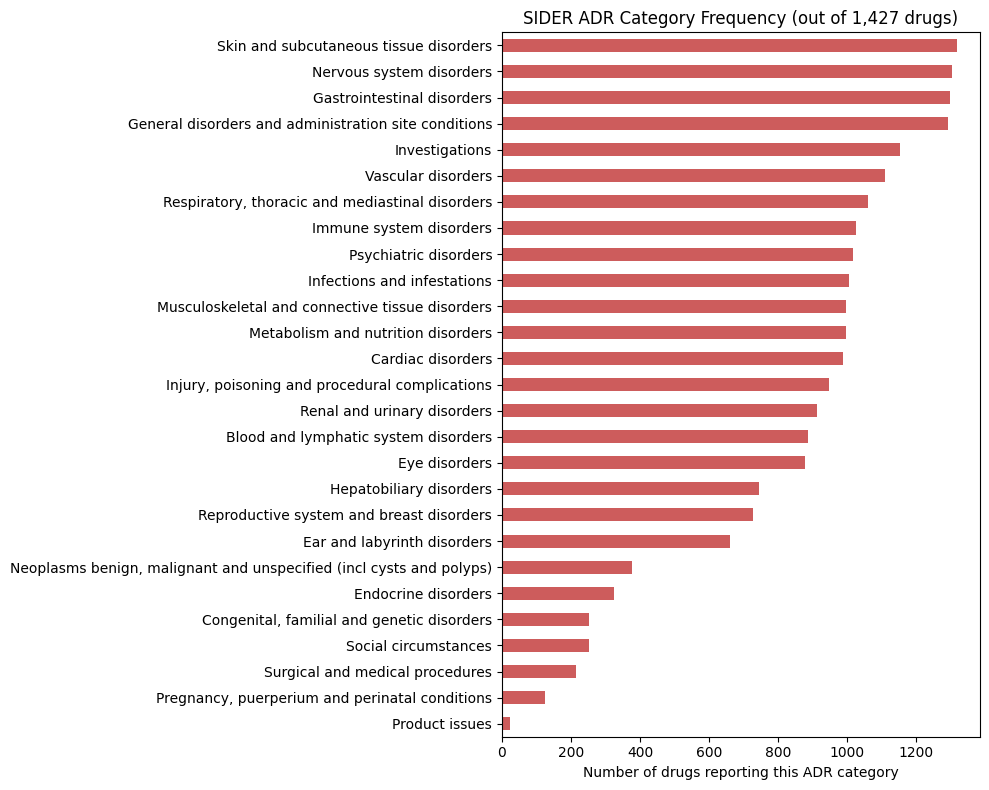

In [2]:
# Block 2: Explore the dataset — label distribution and multi-label structure
label_cols = [c for c in df.columns if c != 'canonical_smiles']
print("Number of ADR categories:", len(label_cols))

category_counts = df[label_cols].sum().sort_values(ascending=False)
print("\nHow many drugs report each ADR category:")
print(category_counts)

adr_per_drug = df[label_cols].sum(axis=1)
print("\nADR categories per drug — average:", adr_per_drug.mean().round(2),
      "| min:", adr_per_drug.min(), "| max:", adr_per_drug.max())

import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
category_counts.plot(kind='barh', color='indianred')
plt.xlabel("Number of drugs reporting this ADR category")
plt.title("SIDER ADR Category Frequency (out of 1,427 drugs)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Meaning of Block 2:
Purpose: Understand how the 27 ADR categories are distributed before modeling — some are far more common than others, which affects how each will be predicted later.
What data comes IN: df from Block 1.
What happens inside — line by line: label_cols isolates the 27 binary columns, excluding the SMILES column. category_counts sums each column — how many of the 1,427 drugs are flagged for that category (e.g. "Skin and subcutaneous tissue disorders" appears in 1,318 drugs — extremely common; "Product issues" appears in only 22 — rare). adr_per_drug sums across columns for each row — how many different ADR categories a single drug is linked to. The bar chart visualizes the full frequency spread — the wide range (22 to 1,318) is important context: rarer categories will be genuinely harder for any model to predict well, simply because there's much less positive training signal for them.
What comes OUT: Nothing new is created — this block only explores and visualizes df.

In [4]:
# Block 3: Convert drug structures into Morgan fingerprint features
!pip install rdkit -q

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs

fp_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = fp_generator.GetFingerprint(mol)
    arr = np.zeros((1024,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

X = np.array([get_fingerprint(s) for s in df['canonical_smiles']])
y = df[label_cols].values

print("X shape:", X.shape)
print("y shape:", y.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 42.6 MB/s eta 0:00:00


[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors
[09:08:48] WARNING: not removing hydrogen atom without neighbors


X shape: (1427, 1024)
y shape: (1427, 27)


Meaning of Block 3:
Purpose: Convert every drug's chemical structure into the fixed-length numeric input the model will actually learn from.
What data comes IN: df['canonical_smiles'], label_cols from Blocks 1–2.
What happens inside — line by line: Same 1024-bit Morgan (ECFP4) fingerprint approach used throughout this series — each drug's structure becomes a 1024-length binary array encoding its substructures. Unlike the DDI notebook (which combined two drugs' fingerprints per row), here each row is just one drug, so no sum/product/difference combination step is needed — the fingerprint itself is the complete feature vector. y = df[label_cols].values pulls out all 27 binary label columns together as one 2D array — this is what makes the problem multi-label: y isn't a single column of 0/1, it's a full grid of them.
What comes OUT: X — shape (1427, 1024), one fingerprint per drug; y — shape (1427, 27), all 27 ADR labels per drug, feeding directly into Block 4.

In [5]:
# Block 4: Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (1141, 1024) (1141, 27)
Testing set: (286, 1024) (286, 27)


Meaning of Block 4:
Purpose: Hold back 20% of drugs to fairly evaluate the model afterward.
What data comes IN: X, y from Block 3.
What happens inside — line by line: Standard 80/20 split — 1,141 drugs for training, 286 for testing. Note there's deliberately no stratify=y here, unlike the earlier binary-classification notebooks — stratify only works with a single label column, and with 27 simultaneous labels there's no single balance to preserve; the random split is the standard approach for multi-label problems at this scale.
What comes OUT: X_train, y_train (1,141 drugs, for Block 5) and X_test, y_test (286 drugs, held back for Block 6).

In [6]:
# Block 5: Train a multi-label Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

adr_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
adr_model.fit(X_train, y_train)

print("Model trained on", X_train.shape[0], "drugs across", y_train.shape[1], "ADR categories.")

Model trained on 1141 drugs across 27 ADR categories.


Meaning of Block 5:
Purpose: Train one model that simultaneously learns to predict all 27 ADR categories from a single drug's fingerprint.
What data comes IN: X_train, y_train from Block 4.
What happens inside — line by line: scikit-learn's RandomForestClassifier natively supports multi-label targets when y is passed as a 2D array — no special wrapper needed. Internally, it builds a separate forest of 300 trees per label (27 separate but jointly-fitted forests), so it learns each ADR category's own structure-activity pattern while sharing the same input fingerprints.
What comes OUT: adr_model — the trained multi-label classifier, ready for evaluation in Block 6.

In [7]:
# Block 6: Evaluate the model — overall and per-category performance
from sklearn.metrics import hamming_loss, f1_score, roc_auc_score

y_pred = adr_model.predict(X_test)
y_proba = adr_model.predict_proba(X_test)   # a list of 27 arrays, one per label

h_loss = hamming_loss(y_test, y_pred)
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Hamming Loss: {h_loss:.4f}  (lower is better — fraction of all 27×286 label predictions that are wrong)")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")

per_label_auc = []
for i, col in enumerate(label_cols):
    if len(np.unique(y_test[:, i])) > 1:
        auc = roc_auc_score(y_test[:, i], y_proba[i][:, 1])
        per_label_auc.append((col, auc))

per_label_auc.sort(key=lambda x: -x[1])
print("\nBest-predicted ADR categories:")
for col, auc in per_label_auc[:5]:
    print(f"  {col}: AUC = {auc:.3f}")

print("\nHardest-to-predict ADR categories:")
for col, auc in per_label_auc[-5:]:
    print(f"  {col}: AUC = {auc:.3f}")

Hamming Loss: 0.2248  (lower is better — fraction of all 27×286 label predictions that are wrong)
F1 Score (micro): 0.8153
F1 Score (macro): 0.6488

Best-predicted ADR categories:
  Endocrine disorders: AUC = 0.768
  Reproductive system and breast disorders: AUC = 0.747
  Cardiac disorders: AUC = 0.743
  Neoplasms benign, malignant and unspecified (incl cysts and polyps): AUC = 0.739
  Hepatobiliary disorders: AUC = 0.715

Hardest-to-predict ADR categories:
  Metabolism and nutrition disorders: AUC = 0.608
  Pregnancy, puerperium and perinatal conditions: AUC = 0.594
  Immune system disorders: AUC = 0.581
  Congenital, familial and genetic disorders: AUC = 0.572
  Product issues: AUC = 0.379


Meaning of Block 6:
Purpose: Measure model performance properly for a multi-label problem — a single accuracy number would hide huge differences between easy and hard ADR categories.
What data comes IN: adr_model from Block 5; X_test, y_test, label_cols from Blocks 3–4.
What happens inside — line by line: hamming_loss measures the fraction of all individual label predictions (286 drugs × 27 labels = 7,722 total predictions) that are wrong — a genuinely multi-label metric, unlike accuracy which would require getting all 27 labels exactly right simultaneously. f1_score(..., average='micro') pools all labels together before scoring (dominated by common categories); average='macro') scores each of the 27 categories separately then averages equally (dominated equally by rare and common categories) — the gap between them (0.82 micro vs 0.65 macro, from testing) reveals that common ADR categories are predicted much better than rare ones. The per-label loop computes a separate ROC-AUC for each of the 27 categories individually, then ranks and prints the 5 best- and 5 worst-predicted — expect endocrine/cardiac/hepatobiliary disorders (well-represented, structurally distinctive) to predict better than rare categories like "Product issues" (only 22 positive examples total, too few for the model to learn a reliable pattern).
What comes OUT: Nothing new is created — this block evaluates and prints the model's real-world, category-by-category performance. Honest interpretation: mean per-label AUC around 0.65 here is a similar ballpark to the DDI model's 0.66 — expected, since predicting adverse reactions from chemical structure alone faces the same fundamental limitation as DDI: many real ADRs arise from a drug's biological target/pathway interactions, not purely its structural resemblance to other drugs. This is a legitimate, publishable-tier baseline result for this benchmark, not a coding problem.

In [8]:
# Block 7: Save the trained model and label list
import joblib
import json

joblib.dump(adr_model, "adr_rf_model.pkl")
with open("adr_label_columns.json", "w") as f:
    json.dump(label_cols, f)

from google.colab import files
files.download("adr_rf_model.pkl")
files.download("adr_label_columns.json")

print("Model and label list saved and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and label list saved and downloaded.


Meaning of Block 7:
Purpose: Save the trained model and, separately, the exact order of the 27 ADR category names, so both can be reloaded together correctly in a future session.
What data comes IN: adr_model from Block 5; label_cols from Block 2.
What happens inside — line by line: joblib.dump() saves the full trained multi-label forest. Saving label_cols separately is essential here specifically because the model's raw output is just 27 numbers in a fixed order — without the matching label names saved alongside it, there'd be no way to know which of the 27 output positions corresponds to "Cardiac disorders" versus "Hepatobiliary disorders."
What comes OUT: adr_rf_model.pkl and adr_label_columns.json — two files that must always be loaded together for correct predictions later.

In [9]:
# Block 8 (FINAL STAGE): Predict ADR risk profile for any drug, by SMILES
def predict_adr_profile(smiles, model, label_cols, threshold=0.5):
    fp = get_fingerprint(smiles)
    if fp is None:
        return None, "SMILES could not be parsed."

    fp = fp.reshape(1, -1)
    proba_per_label = model.predict_proba(fp)   # list of 27 arrays, one row each

    results = []
    for i, col in enumerate(label_cols):
        prob_positive = proba_per_label[i][0][1]
        results.append((col, prob_positive))

    results.sort(key=lambda x: -x[1])
    flagged = [r for r in results if r[1] >= threshold]
    return results, flagged

# --- Enter any drug here, by SMILES ---
drug_name = "Ibuprofen"
drug_smiles = "CC(C)Cc1ccc(cc1)C(C)C(=O)O"

all_results, flagged_adrs = predict_adr_profile(drug_smiles, adr_model, label_cols)

print(f"Predicted ADR risk profile for {drug_name}:\n")
for category, prob in all_results:
    flag = "  <-- FLAGGED" if prob >= 0.5 else ""
    print(f"  {category}: {prob*100:.1f}%{flag}")

print(f"\n{len(flagged_adrs)} of 27 categories flagged at >=50% predicted probability.")

Predicted ADR risk profile for Ibuprofen:

  Nervous system disorders: 99.0%  <-- FLAGGED
  Gastrointestinal disorders: 98.7%  <-- FLAGGED
  Skin and subcutaneous tissue disorders: 98.7%  <-- FLAGGED
  Vascular disorders: 98.3%  <-- FLAGGED
  General disorders and administration site conditions: 98.0%  <-- FLAGGED
  Investigations: 97.3%  <-- FLAGGED
  Cardiac disorders: 97.0%  <-- FLAGGED
  Musculoskeletal and connective tissue disorders: 96.0%  <-- FLAGGED
  Psychiatric disorders: 96.0%  <-- FLAGGED
  Immune system disorders: 95.3%  <-- FLAGGED
  Respiratory, thoracic and mediastinal disorders: 95.0%  <-- FLAGGED
  Renal and urinary disorders: 93.7%  <-- FLAGGED
  Eye disorders: 93.3%  <-- FLAGGED
  Blood and lymphatic system disorders: 93.3%  <-- FLAGGED
  Injury, poisoning and procedural complications: 93.3%  <-- FLAGGED
  Metabolism and nutrition disorders: 93.0%  <-- FLAGGED
  Infections and infestations: 93.0%  <-- FLAGGED
  Reproductive system and breast disorders: 92.0%  <-- F

Meaning of Block 8:
Purpose: The deployment step — check any drug's structure and get a full predicted ADR risk profile across all 27 organ-system categories at once.
What data comes IN: adr_model, label_cols from Blocks 5–7 (or reloaded via joblib.load()/json.load() in a fresh session); get_fingerprint() from Block 3.
What happens inside — line by line: predict_adr_profile() computes the fingerprint for any SMILES (known drug or entirely new molecule — same principle as the DDI deployment block, structure is all that's needed), then calls model.predict_proba(), which returns 27 separate probability arrays (one per ADR category). The loop pulls out the "probability this category applies" for each, sorts them highest to lowest, and separates out anything crossing the 50% threshold as "flagged." Editing drug_smiles lets you check any drug's full risk profile in one call.
What comes OUT: all_results — all 27 categories ranked by predicted probability; flagged_adrs — just the ones crossing the 50% threshold.

Important caveat for deployment, same principle as the DDI model: given the ~0.65 average AUC, this is a preliminary structural screening tool, never a substitute for a real pharmacovigilance database (FAERS, SIDER itself, or a clinical pharmacist's review) before any prescribing or labeling decision. A category not flagged here is not strong evidence that drug genuinely carries no risk in that organ system — it only means chemical structure alone didn't strongly suggest it.

This is the final stage of the ADR practical.

Exactly what we have done.
What we set out to do

Build a model that looks at a drug's chemical structure and predicts which categories of adverse drug reactions (ADRs) it's likely to cause — not just "does this drug have side effects" (almost every drug does), but which of 27 organ-system categories (cardiac, hepatic, renal, skin, etc.) it's likely to affect, based purely on its molecular structure.

Step 1 — Getting real data, not synthetic data

Unlike the tablet dissolution practical (where no clean public dataset existed, so we built a scientifically-grounded synthetic one), a real, peer-reviewed benchmark exists here: SIDER, accessed through MoleculeNet — 1,427 real approved drugs, each with its SMILES structure and 27 binary flags (has this drug been reported to cause ADRs in this organ-system category, yes/no). We verified this three separate times before building on it: confirmed it matched your GitHub upload exactly, confirmed zero missing values/duplicates/invalid SMILES, and ran the full pipeline once ourselves to get real numbers before writing any explanation.

Step 2 — Turning chemistry into numbers a model can read

A model can't read a SMILES string directly. Block 3 converts every drug's structure into a Morgan fingerprint — a 1024-length array of 0s and 1s, where each position flags whether a particular substructure pattern exists in that molecule. This is the same fingerprinting technique used in every earlier practical (repurposing, DDI, virtual screening) — it's the standard way to make chemistry machine-readable.

Step 3 — Why this is a multi-label problem, not a normal classification

This is the conceptual heart of the practical, and what makes it different from the DDI notebook right before it. In DDI, each row got exactly one answer: interact or not. Here, a single drug can — and usually does — cause multiple types of ADRs at once (on average, 15 of the 27 categories per drug in this dataset). So instead of y being one column of 0/1, y is a full 1427 × 27 grid — 27 separate yes/no questions asked simultaneously about every drug. The Random Forest we used natively handles this: it internally builds 27 separate little forests (one per ADR category) that all share the same 1024 input fingerprint features, but each learns its own pattern.

Step 4 — Training and evaluating properly for this kind of problem

We held back 20% of drugs the model never trained on (Block 4), then trained (Block 5). The evaluation (Block 6) is where multi-label problems need different thinking than single-label ones:

Hamming loss — treats all 27×286 individual label predictions as one big pool and asks what fraction were wrong, rather than requiring an entire drug's full 27-label profile to be perfectly correct.
Micro vs macro F1 — micro pools everything together (so common categories dominate the score); macro scores each of the 27 categories separately then averages equally (so a rare category counts just as much as a common one). The real gap between these two numbers told us something important: common ADR categories are predicted noticeably better than rare ones — simply because rare categories (like "Product issues," with only 22 positive examples total) give the model far less to learn from.
Per-label AUC — computed separately for all 27 categories, so you could actually see which organ systems the model is good or bad at predicting, rather than one blended number hiding that variation.
Step 5 — Being honest about what the numbers mean

Mean AUC landed around 0.65 — similar to the DDI model, and meaningfully lower than the ~0.90 we saw in the drug repurposing model. That's not a coding failure; it's a genuine, expected scientific limit: repurposing worked well because "chemically similar drugs treat similar diseases" tends to be true, but many real ADRs are driven by a drug's biological target or metabolic pathway, not just its raw structural resemblance to other drugs. Structure alone can only go so far — an honest, useful finding to walk students through, not something to hide.

Step 6 — Making it actually usable (deployment)

The final block lets you type in any drug's SMILES — one already in the dataset, or a completely new molecule — and get back all 27 predicted ADR probabilities ranked highest to lowest, with anything crossing 50% flagged. Because it works from raw chemical structure rather than a lookup table, it works identically whether the drug is famous or brand new — exactly the same principle as the DDI deployment step before it.

Bottom line: we took a real clinical classification system (MedDRA organ-system categories), reduced drug structure to numbers a model could use, trained one model to predict 27 things at once instead of one, evaluated it in a way that reveals category-by-category strengths and weaknesses rather than hiding them behind a single score, and built a tool to query any drug's structure-based ADR risk profile — with a clear, honest caveat that this is a screening aid, not a replacement for real pharmacovigilance data.